

Breast Cancer Wisconsin Dataset

[K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

Also can be found on UCI Machine Learning Repository:

https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic


**Executive summary**

1. The dataset (Breast Cancer Wisconsin — Diagnostic) was loaded and cleaned; an Unnamed: 32 artifact column was removed and missing values were inspected.

2. The diagnostic label was encoded and the data were split into train / calibration / test sets (≈ 72% / 8% / 20%).

3. Feature multicollinearity was addressed via robust VIF filtering; numeric features were winsorized to reduce outlier influence.

4. Separate pipelines for training (SMOTE + preprocessing + feature selection + classifier) and inference (preprocessing + selector) were constructed, with a factory pattern to avoid shared estimator state.

5. Four base classifiers (Logistic Regression, Decision Tree, Random Forest, SVM) were tuned with GridSearchCV (5-fold Stratified CV) using AUC as the optimization metric.

6. Models were calibrated on an independent calibration fold; calibration was evaluated with Brier scores and calibration curves.

7. Per-model decision thresholds were optimized for F2 score on the calibration fold to favor sensitivity.

8. Test-set performance (accuracy, precision, recall, F1, AUC, Brier) was computed and confusion matrices inspected.

9. A stacking ensemble of calibrated models was trained and evaluated, and its generalization assessed via an outer calibrated CV.

10. SHAP (TreeExplainer) analysis was run on the final Random Forest to provide local/global interpretability; top contributing features were reported.

11. Preprocessing, fitted inference pipeline, calibrated models, thresholds, and SHAP artifacts were saved for deployment and reporting.

12. A workload-estimation step was included to quantify runtime and memory expectations prior to heavy computations.

**Workload estimation & quick environment check**

*A. What this cell does*

- Detects execution environment (Colab vs local).

- Attempts to load the CSV (or prompt the user/upload in Colab).

- Produces a compact dataset summary, class balance, and train/calibration/test split sizes (using the notebook’s split ratios).

- Estimates the total number of model fits implied by the specified grids and CV configuration.

- Runs a small micro-benchmark (cheap Logistic fit on a small subset) and extrapolates a conservative runtime estimate.

- Prints memory and parallelism recommendations.

*B. Methods used & why*

- Environment detection: simple import test for google.colab so the notebook behaves identically in Colab and locally.

- A small train/test split is performed to estimate training sizes without committing to further heavy work.

- Grid and CV combinatorics are enumerated to estimate the number of model fits (helpful when planning runs).

- Micro-benchmarking provides an empirical anchor for extrapolating total wall time — more reliable than theoretical models alone. The code errs on the conservative side (upper bound) to avoid underestimating runtime.

*C. Output analysis (CELL 0 output)*

*Machine-learning / computational interpretation*

- The script successfully detected Colab and required an upload; the uploaded CSV was read and reported shape (569, 32). This is the canonical Breast Cancer Wisconsin dataset size; the notebook is operating on the expected data.

- The dataset contained the Unnamed: 32 auxiliary column; the code flagged it as present and counted missing values. The total missing values were 569 because the entire Unnamed: 32 column is empty — the pipeline later drops this column. This is informational and does not indicate missing labels or measurement gaps in the features used for modeling.

- Class balance: B (benign) = 357, M (malignant) = 212 (≈ 62.8% benign, 37.2% malignant). The imbalance is modest and justifies either rebalancing during training (SMOTE was used in this project) using class-aware metrics and stratification.

- Splits: Train = 409, Calib = 46, Test = 114. The chosen calibration fold is nontrivial and provides an independent set to calibrate predicted probabilities — it was a good experience when final probability estimates matter clinically.

- Fit count estimate: a conservative upper bound of 555 model fits was reported. Given the grid sizes and nested operations, that magnitude is consistent with a 4-model grid search (4–12 combos each) plus stacking and outer CV. The micro-benchmark extrapolation (~2.9 minutes) is a rough indication that the full experiment is computationally feasible in short order on the runtime used; heavy models like RF and SVM will increase per-fit time, so the actual time is likely longer but still tractable on the environment currently I used.

*Medical / clinical interpretation*

- No clinical measurements were altered in this step; the cell provides operational context only. That said, it is important clinically that class distribution be inspected early: if malignancies were extremely rare, model training and threshold selection would require special caution. Here the malignant class is sufficiently represented to train discriminative models and to estimate calibration without severely underpowering probability estimates.

*Notes & takeaways*

- The presence of the empty Unnamed: 32 column triggered a warning from scikit-learn during imputation — this is expected and was handled by dropping the column later.

- The workload estimation successfully guided configuration (recommendation to use N_JOBS=1 given environment constraints), which helps avoid resource contention during GridSearch.



In [1]:
### Workload estimation & quick environment check

import os, sys, time, math
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
DEFAULT_FILENAME = "breast-cancer-wisconsin-data.csv"

# Detect Colab
ASSUME_COLAB = False
try:
    import google.colab  # type: ignore
    ASSUME_COLAB = True
except Exception:
    ASSUME_COLAB = False

# Try load a CSV minimally to estimate sizes
df = None
if ASSUME_COLAB:
    print("Environment: Colab detected.")
    try:
        from google.colab import files  # type: ignore
        if os.path.exists(DEFAULT_FILENAME):
            df = pd.read_csv(DEFAULT_FILENAME, index_col='id' if 'id' in pd.read_csv(DEFAULT_FILENAME, nrows=0).columns else None)
            print(f"Loaded {DEFAULT_FILENAME} from working dir.")
        else:
            print("No CSV in working dir — please upload via prompt.")
            uploaded = files.upload()
            for fn in uploaded:
                if fn.lower().endswith(".csv"):
                    try:
                        df = pd.read_csv(fn, index_col='id' if 'id' in pd.read_csv(fn, nrows=0).columns else None)
                        print(f"Loaded uploaded file: {fn}")
                        break
                    except Exception as e:
                        print("Failed to read uploaded file:", e)
    except Exception as e:
        print("Colab upload attempt failed:", e)
else:
    # local environment: try default filename first, else ask user for path
    if os.path.exists(DEFAULT_FILENAME):
        df = pd.read_csv(DEFAULT_FILENAME, index_col='id' if 'id' in pd.read_csv(DEFAULT_FILENAME, nrows=0).columns else None)
        print(f"Loaded {DEFAULT_FILENAME} from working dir.")
    else:
        # find candidate
        candidates = [f for f in os.listdir('.') if f.lower().endswith('.csv') and 'breast' in f.lower()]
        if candidates:
            df = pd.read_csv(candidates[0], index_col='id' if 'id' in pd.read_csv(candidates[0], nrows=0).columns else None)
            print(f"Loaded candidate CSV: {candidates[0]}")
        else:
            path = input(f"CSV not found. Enter CSV path (or press Enter to abort): ").strip()
            if not path:
                raise FileNotFoundError("No CSV provided. Place the CSV in the working dir or provide a path.")
            df = pd.read_csv(path, index_col='id' if 'id' in pd.read_csv(path, nrows=0).columns else None)
            print(f"Loaded CSV from: {path}")

# Basic summary
print("\n--- Dataset summary ---")
print("Shape:", df.shape)
cols_preview = list(df.columns[:10])
print("Columns (first 10):", cols_preview)
if 'Unnamed: 32' in df.columns:
    print("Note: file contains 'Unnamed: 32' column — will be dropped later if present.")
na_counts = df.isna().sum()
total_nans = int(na_counts.sum())
print("Total missing values:", total_nans)
if total_nans > 0:
    print("Top missing cols:\n", na_counts[na_counts > 0].sort_values(ascending=False).head())

# quick target check
if 'diagnosis' in df.columns:
    print("\nTarget 'diagnosis' value counts:")
    print(df['diagnosis'].value_counts())
else:
    print("\nWarning: 'diagnosis' column not found. Notebook expects this column.")

# quick split to compute sizes (used only for estimation)
try:
    y = df['diagnosis']
    X = df.drop(columns=['diagnosis'])
    y_enc_dummy = pd.factorize(y)[0]
    X_temp, X_test, y_temp, y_test = train_test_split(X, y_enc_dummy, test_size=0.2, stratify=y_enc_dummy, random_state=RANDOM_STATE)
    X_train, X_calib, y_train, y_calib = train_test_split(X_temp, y_temp, test_size=0.1, stratify=y_temp, random_state=RANDOM_STATE)
    print("\nSplits → Train:", len(X_train), "Calib:", len(X_calib), "Test:", len(X_test))
except Exception as e:
    print("Could not compute splits for estimation:", e)

# hypergrids used later (conservative)
grids = {
    'Logistic': {'clf__C': [0.01, 0.1, 1, 10]},
    'DecisionTree': {'clf__max_depth': [None, 5, 10, 20]},
    'RandomForest': {'clf__n_estimators': [50, 100, 200], 'clf__max_depth': [None, 5, 10]},
    'SVM': {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear','rbf'], 'clf__gamma': ['scale','auto']}
}
cv_folds = 5
total_grid_fits = 0
for name, g in grids.items():
    combos = 1
    for v in g.values():
        combos *= len(v)
    fits = combos * cv_folds + 1
    total_grid_fits += fits

# rough estimate for heavy outer CV in CELL 11 (conservative)
n_base = 3
stacking_inner_cv = 5
outer_cv = 5
fits_per_ensemble_fit = n_base * stacking_inner_cv + 1
outer_total_fits = outer_cv * (stacking_inner_cv * fits_per_ensemble_fit)
estimated_total_fits = total_grid_fits + (1 + len(grids) + 1) + outer_total_fits  # include stacking & calibrations

print("\n--- Fit count estimates ---")
print(f"Estimated total model fits (conservative upper bound): {estimated_total_fits}")

# micro-benchmark (cheap logistic on subset)
print("\n--- Micro-benchmark (quick extrapolation) ---")
try:
    sample_n = min(200, max(50, int(0.02 * len(X_train))))
    X_sub = X_train.sample(sample_n, random_state=RANDOM_STATE)
    bench_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    t0 = time.time()
    bench_pipe.fit(X_sub, y_train[:sample_n])
    t1 = time.time()
    single_fit_time = max(1e-4, t1 - t0)
    print(f"Observed time on {sample_n} rows: {single_fit_time:.4f} s")
    avg_rows = len(X_train)
    scale_factor = avg_rows / sample_n
    estimated_time_total_s = single_fit_time * scale_factor * estimated_total_fits
    print(f"Rough extrapolation: ≈ {estimated_time_total_s/60.0:.1f} minutes ({estimated_time_total_s/3600.0:.2f} hours).")
except Exception as e:
    print("Micro-benchmark failed:", e)

print("\nRecommendations:")
print(" - If on low-RAM (<8GB) environment, set N_JOBS=1.")
print(" - CELL 10 is heavy; keep cv=5 as desired but be aware it may take long.")
print("Workload estimation complete.\n")


Environment: Colab detected.
No CSV in working dir — please upload via prompt.


Saving breast-cancer-wisconsin-data.csv to breast-cancer-wisconsin-data.csv
Loaded uploaded file: breast-cancer-wisconsin-data.csv

--- Dataset summary ---
Shape: (569, 32)
Columns (first 10): ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean']
Note: file contains 'Unnamed: 32' column — will be dropped later if present.
Total missing values: 569
Top missing cols:
 Unnamed: 32    569
dtype: int64

Target 'diagnosis' value counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Splits → Train: 409 Calib: 46 Test: 114

--- Fit count estimates ---
Estimated total model fits (conservative upper bound): 555

--- Micro-benchmark (quick extrapolation) ---
Observed time on 50 rows: 0.0380 s
Rough extrapolation: ≈ 2.9 minutes (0.05 hours).

Recommendations:
 - If on low-RAM (<8GB) environment, set N_JOBS=1.
 - CELL 10 is heavy; keep cv=5 as desired but be aware it may t

/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



**Imports & smarter N_JOBS**

*A. What this cell does*

- Imports required libraries and sets reproducible randomness.

- Detects CPU count and (if available) total RAM to compute a heuristic N_JOBS to use for parallel operations.

*B. Methods used & why*

- multiprocessing.cpu_count() and optional psutil memory query are used to produce a memory-aware parallelism recommendation. The intent is to avoid oversubscription on multi-core machines, and to prevent excessive memory pressure that would slow or crash grid searches. Conservative defaults (use cpu_count - 1) are retained unless memory suggests stricter limits.

*C. Output analysis*

*Machine-learning / computational interpretation*

- The runtime detected 2 CPUs and ~12.7 GB RAM; N_JOBS was set to 1. This conservative setting avoids nested parallelism and is appropriate for reproducible GridSearch runs on modest machines. The choice ensures that each heavy estimator (e.g., Random Forest) does not attempt to parallelize internally and that GridSearch itself uses a single worker — avoiding memory thrashing while still preserving correctness.

*Medical interpretation*

- No clinical content produced here; the cell purpose is computational safety. Ensuring stable computation is clinically relevant indirectly because unstable runs can produce inconsistent model fits or prematurely terminated experiments, which would undermine any clinical conclusions.


In [2]:
### Imports & Setup

# Standard library
import os
import sys
import math
import joblib
import sklearn
import multiprocessing

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, cross_val_score, learning_curve
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score,
    confusion_matrix, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

# Statistical models
import statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Interpretability
import shap

# Reproducibility
RANDOM_STATE = 42

# Determine sensible N_JOBS based on CPU & memory heuristics
N_CPUS = multiprocessing.cpu_count() or 1
# try to get memory via psutil if available
try:
    import psutil
    total_mem_gb = psutil.virtual_memory().total / (1024**3)
except Exception:
    total_mem_gb = None

# Heuristic:
# - prefer cpu_count - 1
# - but cap by memory: require approx 3-4 GB per job (conservative)
if total_mem_gb is not None:
    # allow at least 1 job; compute by memory
    max_jobs_by_mem = max(1, int(total_mem_gb // 4))
    N_JOBS = max(1, min(N_CPUS - 1, max_jobs_by_mem))
else:
    # no mem info: be conservative
    N_JOBS = max(1, N_CPUS - 1 if N_CPUS > 2 else 1)

# final safety clamp
N_JOBS = int(max(1, min(N_JOBS, N_CPUS)))

print(f"Detected CPUs: {N_CPUS}, total_mem_gb: {total_mem_gb if total_mem_gb is not None else 'unknown'} -> Using N_JOBS = {N_JOBS}")


Detected CPUs: 2, total_mem_gb: 12.673782348632812 -> Using N_JOBS = 1



**Load & Basic Cleaning**

*A. What this cell does*

- Loads the CSV robustly (Colab upload or local path as needed).

- Drops the Unnamed: 32 empty column if present.

- Prints per-column counts of missing values, without asserting no-NaN (because the preprocessing pipeline will impute).

*B. Methods used & why*

- A Colab-friendly loader is used to preserve the original notebook behavior while maintaining compatibility with local runs.

- The notebook does not force an early failure for NaNs because an explicit imputation step is part of the pipeline; reporting missing-value counts is sufficient to verify data quality.

*C. Output analysis*

*Machine-learning interpretation*

- The CSV was successfully loaded and Unnamed: 32 was dropped. After that, the dataset contained no missing values (total missing values: 0). From a modeling standpoint, this confirms the features used going forward are complete and compatible with the pipelines (which still include an imputer as best practice). There is no indication of missing labels or partial features that would complicate training.

*Medical interpretation*

- Data integrity is a necessary prerequisite for clinical inferences. Having a clean dataset means the morphological features derived from cytological images were correctly parsed and are ready for reproducible modeling. No evidence of missing clinical annotations (diagnosis) was found in this step.


In [3]:
### Load & Basic Cleaning

import os

DEFAULT_FILENAME = "breast-cancer-wisconsin-data.csv"

# Detect Colab and prefer the same uploading mechanism there
IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

def load_csv_prefer_colab(default=DEFAULT_FILENAME):
    # If running in Colab: use files.upload() if CSV not already in working dir
    if IN_COLAB:
        from google.colab import files  # type: ignore
        if os.path.exists(default):
            try:
                df = pd.read_csv(default, index_col='id' if 'id' in pd.read_csv(default, nrows=0).columns else None)
                print(f"Loaded {default} from working dir.")
                return df
            except Exception as e:
                print("Failed to read default CSV in working dir:", e)
        print("No default CSV found in working dir — please upload file via the prompt.")
        uploaded = files.upload()
        # pick first CSV-like
        for fn in uploaded:
            if fn.lower().endswith('.csv'):
                df = pd.read_csv(fn, index_col='id' if 'id' in pd.read_csv(fn, nrows=0).columns else None)
                print(f"Loaded uploaded file: {fn}")
                return df
        raise FileNotFoundError("No CSV uploaded.")
    else:
        # Not Colab: prefer default file in working dir, else prompt user to provide path
        if os.path.exists(default):
            df = pd.read_csv(default, index_col='id' if 'id' in pd.read_csv(default, nrows=0).columns else None)
            print(f"Loaded {default} from working dir.")
            return df
        # look for candidate
        candidates = [f for f in os.listdir('.') if f.lower().endswith('.csv') and 'breast' in f.lower()]
        if candidates:
            fn = candidates[0]
            df = pd.read_csv(fn, index_col='id' if 'id' in pd.read_csv(fn, nrows=0).columns else None)
            print(f"Loaded candidate file: {fn}")
            return df
        # otherwise ask user for path (works in notebook)
        path = input(f"CSV not found. Enter path to CSV (or press Enter to abort): ").strip()
        if not path:
            raise FileNotFoundError("No CSV provided. Place the CSV in the working dir or provide a path.")
        df = pd.read_csv(path, index_col='id' if 'id' in pd.read_csv(path, nrows=0).columns else None)
        print(f"Loaded CSV from: {path}")
        return df

# Load dataset
df = load_csv_prefer_colab(DEFAULT_FILENAME)

# Drop the Unnamed column if present
if 'Unnamed: 32' in df.columns:
    df.drop(columns=['Unnamed: 32'], inplace=True)
    print("Dropped column 'Unnamed: 32'.")

# Do not assert no NaNs since pipeline will impute later
# Give a NaN summary
na_counts = df.isna().sum()
total_nans = int(na_counts.sum())
print(f"Total missing values: {total_nans}")
if total_nans > 0:
    print("Missing values per column (top 10):\n", na_counts[na_counts > 0].sort_values(ascending=False).head(10))

# Ensure diagnosis exists
if 'diagnosis' not in df.columns:
    raise KeyError("Expected column 'diagnosis' not found in CSV. Check file columns.")


Loaded breast-cancer-wisconsin-data.csv from working dir.
Dropped column 'Unnamed: 32'.
Total missing values: 0



**Encode Target & Split Data**

*A. What this cell does*

- Encodes the diagnosis label into numeric form.

- Splits the dataset into training, calibration and test sets using stratified random splits: first test split 20%, then calibration split 10% of the remaining training set — resulting in Train = 409, Calib = 46, Test = 114.

*B. Methods used & why*

- LabelEncoder is used to map categories to integers for compatibility with scikit-learn.

- train_test_split with stratify preserves the class balance across splits: this prevents bias when evaluating models and calibrating probabilities on small calibration folds.

*C. Output analysis*

*Machine-learning interpretation*

- Splits are consistent with the earlier workload estimation. The calibration fold size (n=46) is modest but usable for calibrating probabilities (e.g., via Platt/sigmoid), provided overfitting is controlled. Stratification preserved class proportions across train, calibration, and test sets, which is critical for reliable performance estimates and threshold tuning.

*Medical interpretation*

- The test fold of 114 patients provides a realistic small-cohort performance estimate. For clinical deployment, a larger external validation would be preferable, but the current split allows rigorous within-dataset assessment of discrimination and calibration that informs whether the model is ready for further validation.


In [4]:
### Encode Target & Split Data

# Encode diagnosis and split into train, calibration, and test
y = df['diagnosis']
X = df.drop(columns=['diagnosis'])
y_enc = LabelEncoder().fit_transform(y)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=RANDOM_STATE)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.1, stratify=y_temp, random_state=RANDOM_STATE)
print(f"Splits → Train: {len(X_train)}, Calib: {len(X_calib)}, Test: {len(X_test)}")
assert sorted(np.unique(y_train)) == [0,1], "Target encoding error"


Splits → Train: 409, Calib: 46, Test: 114



**Robust VIF filtering + Winsorization**

*A. What this cell does*

- Selects numeric features only.

- Computes variance inflation factor (VIF) per numeric feature (robust to exceptions).

- Applies a VIF threshold (≤ 10.0). If no features pass, falls back to keeping the k features with smallest VIF (a safety fallback).

- Applies winsorization (clipping) to numeric columns at the 5th and 95th percentiles to reduce the impact of extreme values.

*B. Methods used & why*

- VIF: used to detect multicollinearity among numeric predictors. High multicollinearity inflates variance of coefficient estimates and may harm feature selection or model interpretability. A common practical cutoff is VIF > 10. The code is intentionally robust (it falls back to the least collinear set if none pass the threshold).

- Winsorization: capping at 5th/95th percentiles prevents extreme outliers from dominating scaling and model fitting, particularly important when using StandardScaler and SelectFromModel.

*C. Output analysis*

*Machine-learning interpretation*

- The algorithm found no features with VIF ≤ 10, so it fell back to the top 7 features with the smallest VIF values: **['texture_se', 'smoothness_se', 'fractal_dimension_se', 'concavity_se', 'compactness_se', 'symmetry_se', 'concave points_se']**. This indicates the original feature set contains substantial multicollinearity — not surprising because many morphology metrics are strongly correlated (area/perimeter-related measures, etc.). The fallback is appropriate: it keeps the least collinear subset to stabilize subsequent feature selection and reduce redundancy.

- Winsorization ensures that extreme observations do not overly influence the L1-based feature selection and downstream classifiers.

*Medical interpretation*

- The selected features correspond to morphological descriptors, specifically standard error measurements (*_se) that quantify variation across segmented cells or measurement uncertainty. The presence of features such as concave points, symmetry, concavity, compactness, texture, and smoothness among the selected variables is clinically plausible: malignancies often manifest as irregular (concave) borders, increased heterogeneity (texture), and altered symmetry at the cellular / nuclear level. By reducing multicollinearity and focusing on these specific measures, the modeling pipeline emphasizes physiologically meaningful variation. That said, removing many correlated features reduces redundancy but may discard subtle, complementary signals; this trade-off was considered and the fallback of keeping several least-collinear features preserves diverse morphological aspects.

*Notes & takeaways*

- The VIF fallback preserved 7 interpretable features — a manageable and explainable predictor set for clinicians. Winsorization keeps model training robust to a few extreme images or segmentation artifacts.



In [5]:
### Robust VIF filtering + Winsorization

# Compute VIF on numeric columns only and guard against removing all features
num = X_train.select_dtypes(include=[np.number]).copy()
if num.shape[1] == 0:
    raise ValueError("No numeric features found in X_train.")

# Compute VIF values robustly (handle any exceptions)
vif_vals = []
for i in range(num.shape[1]):
    try:
        v = variance_inflation_factor(num.values, i)
    except Exception as e:
        # If VIF can't be computed for this column, set to a large value so it's deprioritized
        v = np.inf
    vif_vals.append(v)

vif_df = pd.DataFrame({'feature': num.columns, 'VIF': vif_vals})
# Replace infinities with a large number for sorting/selection
vif_df['VIF'] = vif_df['VIF'].replace([np.inf, -np.inf], 1e9)

# Preferred threshold
VIF_THRESHOLD = 10.0
keep = vif_df[vif_df['VIF'] <= VIF_THRESHOLD]['feature'].tolist()

# If no features pass the threshold, fall back to keeping the N features with smallest VIF
if len(keep) == 0:
    # choose at least 3 features, up to all features
    fallback_k = min(max(3, num.shape[1] // 4), num.shape[1])
    keep = vif_df.sort_values('VIF').head(fallback_k)['feature'].tolist()
    print(f"Warning: no features with VIF <= {VIF_THRESHOLD}. Falling back to top {len(keep)} features by VIF.")

# Final safety: if still empty (very unlikely), keep all numeric features
if len(keep) == 0:
    keep = list(num.columns)
    print("Warning: fallback still returned zero features. Keeping all numeric features.")

print(f"Selected {len(keep)} features after VIF filtering (example: {keep[:10]}).")

# Keep only selected features in all splits (use .copy() to avoid chained indexing)
X_train = X_train[keep].copy()
X_calib  = X_calib[keep].copy()
X_test   = X_test[keep].copy()

# Winsorize numeric columns (cap at 5th/95th percentiles)
def winsorize(df):
    low, high = df.quantile(0.05), df.quantile(0.95)
    return df.clip(low, high, axis=1)

X_train = winsorize(X_train)
X_calib  = winsorize(X_calib)
X_test   = winsorize(X_test)

# Final sanity checks
if X_train.shape[1] == 0:
    raise ValueError("After VIF filtering no features remain in X_train. Aborting.")
assert not X_train.isna().any().any(), "NaNs found in X_train after VIF/winsorize"


Selected 7 features after VIF filtering (example: ['texture_se', 'smoothness_se', 'fractal_dimension_se', 'concavity_se', 'compactness_se', 'symmetry_se', 'concave points_se']).



**Define Training vs. Inference Pipelines**

*A. What this cell does*

- Introduces factory functions that construct fresh inference and training pipelines.

- The inference pipeline performs imputation → scaling → L1-based feature selection (with SelectFromModel(LogisticRegression, penalty='l1')).

- The training pipeline includes SMOTE for oversampling minority class before selection and classification.

*B. Methods used & why*

- Factory pattern is used to prevent sharing a single SelectFromModel instance among multiple pipelines (avoids state leakage and fitted/unfitted conflicts).

- SMOTE in the training pipeline addresses class imbalance by synthetically oversampling the minority class, improving classifier sensitivity to malignant cases.

- SelectFromModel with L1 logistic selects features in a model-aware manner, consistent with the desire for sparse, interpretable feature sets.


*Machine-learning Notes*

- The separation between training and inference pipelines is deliberate and correct: SMOTE is applied only during training to help the classifier learn a decision boundary that accounts for the underrepresented class, while the inference pipeline remains pure (no synthetic samples) to ensure deterministic transforms at deployment time.

*Medical Notes*

- Using SMOTE for the malignant class helps the model to be more sensitive to malignancies, which is often clinically desirable. This design choice supports downstream threshold optimization that favors recall (as performed later).


In [6]:
### Define Training vs. Inference Pipelines (factory pattern)

from sklearn.base import clone
from sklearn.feature_selection import SelectFromModel

def make_inference_pipeline(selector_C=1.0):
    """Return a fresh inference pipeline (imputer -> scaler -> selector)."""
    sel = SelectFromModel(
        LogisticRegression(penalty='l1', solver='saga', C=selector_C, max_iter=10000,
                           random_state=RANDOM_STATE),
        threshold='mean'
    )
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('feat_sel', sel)
    ])

def make_train_pipeline_with_clf(clf_obj, selector_C=1.0):
    """Return a fresh training pipeline (imputer -> scaler -> SMOTE -> selector -> clf).
       The selector here is a fresh SelectFromModel instance (not shared).
    """
    sel = SelectFromModel(
        LogisticRegression(penalty='l1', solver='saga', C=selector_C, max_iter=10000,
                           random_state=RANDOM_STATE),
        threshold='mean'
    )
    return ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('feat_sel', sel),
        ('clf', clf_obj)
    ])

# Provide a default inference pipeline instance (fresh, can be re-fit later)
inf_pipeline = make_inference_pipeline(selector_C=1.0)



**Model Setup & GridSearchCV**

*A. What this cell does*

- Builds fresh training pipelines for each classifier and performs GridSearchCV (5-fold Stratified CV) optimizing ROC AUC.

- Models tuned: Logistic Regression, Decision Tree, Random Forest, SVM.

- After grid searches, the best estimator for Random Forest is re-fitted for SHAP explainability.

*B. Methods used & why*

- GridSearchCV with StratifiedKFold(5): searches hyperparameter grid while preserving class proportions — the primary model selection mechanism. AUC is the scoring metric to prioritize discrimination across thresholds.

- Error handling and n_jobs are configured conservatively per environment.

- Refitting on the training set ensures downstream explainers (SHAP) operate on fully trained models.

*C. Output analysis*

*Machine-learning interpretation*

- Results summary (best CV AUC and best hyperparameters):

 - Logistic: CV AUC = 0.799, best C = 0.1.

 - DecisionTree: CV AUC = 0.703, best max_depth = 5.

- RandomForest: CV AUC = 0.803, best n_estimators = 200, max_depth = 5.

 - SVM: CV AUC = 0.807, best C = 0.1, kernel = 'rbf', gamma = 'scale'.

- These values are consistent: RF and SVM provide the strongest discrimination (AUC ~0.80–0.81), logistic is close behind, and a single decision tree underperforms the ensembles/regularized linear model — a plausible pattern when informative continuous features exist and regularization/ensembling helps.

- The best RF has max_depth=5 (shallow trees) and many estimators (n_estimators=200), indicating that variance reduction via ensembling and modest tree depth improved generalization. SVM benefits from RBF kernel with moderate regularization (C=0.1) suggesting smooth decision boundaries rather than very complex fits. Logistic with L2-regularization (C=0.1) suggests moderate shrinkage improved stability.

*Medical interpretation*

- The models that best separate malignant from benign examples are RF and SVM (AUC ≈ 0.80+). In clinical terms, an AUC of ~0.80 implies good discriminative ability: the model is likely to correctly rank a malignant case above a benign case about 80% of the time. This is promising for triage applications or as a decision-support tool, but not definitive enough alone for diagnosis — models of this performance are most useful as adjuncts to clinician judgment or to prioritize cases for further testing.

- The hyperparameters indicate relatively conservative complexity (shallow RF, moderate SVM regularization), reducing overfitting risk — important when deploying models to new patient populations.

*Notes & takeaways*

- The grid search results are coherent across algorithms. It is appropriate to proceed to calibration and thresholding to align the probabilistic outputs with clinical decision criteria.


In [7]:
### Model Setup & GridSearchCV

from copy import deepcopy
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.exceptions import FitFailedWarning
import warnings
from sklearn.base import clone

# Helper to construct a fresh train-pipeline for each classifier
def make_pipeline_for_clf(clf_obj, selector_C=1.0):
    return make_train_pipeline_with_clf(clf_obj, selector_C=selector_C)

# Define models (use fresh pipelines for each GridSearch)
models = {
    'Logistic': (
        make_pipeline_for_clf(LogisticRegression(max_iter=10000, random_state=RANDOM_STATE), selector_C=1.0),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
    'DecisionTree': (
        make_pipeline_for_clf(DecisionTreeClassifier(random_state=RANDOM_STATE), selector_C=1.0),
        {'clf__max_depth': [None, 5, 10, 20]}
    ),
    'RandomForest': (
        make_pipeline_for_clf(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1), selector_C=1.0),
        {'clf__n_estimators': [50, 100, 200], 'clf__max_depth': [None, 5, 10]}
    ),
    'SVM': (
        make_pipeline_for_clf(SVC(probability=True, random_state=RANDOM_STATE), selector_C=1.0),
        {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf'], 'clf__gamma': ['scale', 'auto']}
    )
}

# Safety: ensure there is at least one feature
if X_train.shape[1] == 0:
    raise ValueError("X_train has zero features after VIF filtering — can't proceed.")

# CV object
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

best_models = {}
for name, (pipe, grid) in models.items():
    print(f"\nStarting GridSearch for {name} (features: {X_train.shape[1]}) ...")
    # Use N_JOBS computed in CELL 2. Use error_score=np.nan to avoid a single failed param killing the whole search
    gs = GridSearchCV(pipe, grid, cv=cv, scoring='roc_auc', n_jobs=N_JOBS, error_score=np.nan, refit=True)
    try:
        with warnings.catch_warnings():
            # Show FitFailedWarning as a print without raise
            warnings.filterwarnings("default", category=FitFailedWarning)
            gs.fit(X_train, y_train)
        best_models[name] = gs.best_estimator_
        print(f"{name}: best CV AUC={gs.best_score_:.3f}, best_params={gs.best_params_}")
    except Exception as e:
        # If something went catastrophically wrong, capture and continue (It's possible to re-run with smaller grids)
        print(f"GridSearch for {name} failed with exception: {e}")
        # attempt to salvage a fitted estimator if available
        if hasattr(gs, "best_estimator_") and gs.best_estimator_ is not None:
            best_models[name] = gs.best_estimator_
            print(f"Using partial best_estimator_ for {name}.")
        else:
            print(f"No fitted estimator available for {name}. Skipping.")

# Refit / ensure RandomForest pipeline is available and fitted for SHAP
if 'RandomForest' in best_models:
    rf_pipeline_full = best_models['RandomForest']
    # ensure it's fitted; best_estimator_ from GridSearchCV is already fitted by default (refit=True),
    # but re-fitting on full X_train is harmless and ensures consistent state
    try:
        rf_pipeline_full.fit(X_train, y_train)
    except Exception:
        # If refit raises, assume it's already fitted and proceed
        pass
else:
    rf_pipeline_full = None
    print("Warning: RandomForest not found among best_models (SHAP later will error unless present).")



Starting GridSearch for Logistic (features: 7) ...
Logistic: best CV AUC=0.799, best_params={'clf__C': 0.1}

Starting GridSearch for DecisionTree (features: 7) ...
DecisionTree: best CV AUC=0.703, best_params={'clf__max_depth': 5}

Starting GridSearch for RandomForest (features: 7) ...
RandomForest: best CV AUC=0.803, best_params={'clf__max_depth': 5, 'clf__n_estimators': 200}

Starting GridSearch for SVM (features: 7) ...
SVM: best CV AUC=0.807, best_params={'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}



**Calibration & Brier Reporting**

*A. What this cell does*

- Computes the Brier score before and after calibrating each best model on the calibration fold (CalibratedClassifierCV(method='sigmoid', cv='prefit')).

- Builds a stacking ensemble composed of pipelines (preprocessing + classifier) and calibrates the stacking wrapper.

*B. Methods used & why*

- CalibratedClassifierCV (sigmoid): Platt scaling (sigmoid) corrects systematic bias in predicted probabilities while preserving discrimination. Calibration is essential when predicted probabilities are interpreted clinically (e.g., when deciding biopsy thresholds).

- Brier score: measures the mean squared error of predicted probabilities; lower is better and directly quantifies calibration + discrimination quality.

*C. Output analysis*

*Machine-learning interpretation*

- Brier scores improved for all models after calibration:

 - Logistic: 0.167 → 0.151

 - DecisionTree: 0.201 → 0.173

 - RandomForest: 0.175 → 0.161

 - SVM: 0.165 → 0.149

- All models showed meaningful improvements in probabilistic accuracy after Platt scaling. The improvements are modest but consistent; SVM and RF have the best post-calibration Brier scores (~0.149–0.161), suggesting they produce the most reliable probability estimates among the tested algorithms.

*Medical interpretation*

- From a clinical perspective, better calibrated probabilities mean that a predicted probability (for example, 0.7) more closely reflects the true proportion of malignancy in similar cases. Well-calibrated risk estimates are crucial when probabilities are used for shared decision making, e.g., deciding whether to perform an invasive biopsy or recommend short-interval imaging. The observed Brier improvements support the use of calibrated probabilities rather than raw classifier scores in clinical workflows.

*Notes & takeaways*

- Sigmoid calibration on an independent calibration fold was a good practice and improved model reliability without reusing the test set.




In [8]:
### Calibration & Brier Reporting

import warnings
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

calibrated_models = {}

# Calibrate base models (these are pre-fit pipelines from GridSearchCV)
for name, model in best_models.items():
    # model is a fitted pipeline (prep + clf). Use raw X_calib for predict_proba
    pre = brier_score_loss(y_calib, model.predict_proba(X_calib)[:, 1])

    # Temporarily silence the specific deprecation UserWarning about cv='prefit'
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=".*cv='prefit'.*"
        )
        calib = CalibratedClassifierCV(model, cv='prefit', method='sigmoid')
        calib.fit(X_calib, y_calib)

    post = brier_score_loss(y_calib, calib.predict_proba(X_calib)[:, 1])
    print(f"{name}: Brier before={pre:.3f}, after={post:.3f}")
    calibrated_models[name] = calib

# Stacking: build ensemble (base estimators are pipelines that expect raw X)
base = [
    ('lr', Pipeline([('prep', inf_pipeline), ('clf', LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))])),
    ('dt', Pipeline([('prep', inf_pipeline), ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))])),
    ('rf', Pipeline([('prep', inf_pipeline), ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))]))
]

# Use N_JOBS for stacking (safe because stacking is executed standalone here)
ensemble = Pipeline([
    ('stack', StackingClassifier(estimators=base,
                                 final_estimator=LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
                                 cv=5, n_jobs=N_JOBS))
])
ensemble.fit(X_train, y_train)

# Calibrate stacking wrapper and silence deprecation message
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=".*cv='prefit'.*"
    )
    stack_calib = CalibratedClassifierCV(ensemble, cv='prefit', method='sigmoid')
    stack_calib.fit(X_calib, y_calib)

calibrated_models['Stacking'] = stack_calib


Logistic: Brier before=0.167, after=0.151
DecisionTree: Brier before=0.201, after=0.173
RandomForest: Brier before=0.175, after=0.161
SVM: Brier before=0.165, after=0.149



**Threshold Optimization (F2 on calibration fold)**

*A. What this cell does*

- For each calibrated model, the cell searches thresholds in [0,1] (101 grid points) to maximize the F-score with β=2 (F2), emphasizing recall over precision. The chosen threshold is stored for each model.

*B. Methods used & why*

- F2 score: Fβ prioritizes recall when β > 1. In a cancer screening context, missing a malignant case (false negative) can be more costly than a false positive; hence the choice of F2 is clinically motivated. Threshold tuning on the calibration fold aligns the model’s operating point with clinical priorities.

*C. Output analysis*

*Machine-learning interpretation*

- Chosen thresholds and F2 values:

 - Logistic: F2 = 0.876 @ thr = 0.27

 - DecisionTree: F2 = 0.815 @ thr = 0.31

 - RandomForest: F2 = 0.825 @ thr = 0.14

 - SVM: F2 = 0.833 @ thr = 0.11

 - Stacking: F2 = 0.851 @ thr = 0.24

- The optimal thresholds for RF and SVM are notably low (≈0.11–0.14). Low thresholds bias predictions toward the positive class (malignant), increasing sensitivity at the expense of precision — exactly what F2 aims to achieve. Logistic and stacking use somewhat higher thresholds (~0.24–0.31), reflecting different probability distributions and calibration curves.

*Medical interpretation*

- Clinically, a low decision threshold means that even moderate predicted risk will prompt a positive classification (e.g., further imaging or biopsy). That is defensible in screening contexts where missing disease is deemed worse than false alerts; however, it will increase false positive referrals, potentially causing anxiety and additional procedures. The choice of threshold therefore needs to balance expected harms (unnecessary biopsy, downstream costs) against the value of detecting malignancies found only by the model.

*Notes & takeaways*

- Explicit threshold selection tied to F2 is transparent and defensible clinically; stakeholders should confirm acceptable false positive rates before clinical deployment.



In [9]:
### Threshold Optimization

# Threshold tuning (F2) on calibration fold — always use raw X_calib
thresholds = {}
for name, mdl in calibrated_models.items():
    # For all models (including stacking) pass raw X_calib to predict_proba since mdl wraps full pipeline
    probs = mdl.predict_proba(X_calib)[:, 1]
    best_thr, best_f2 = 0.5, 0.0
    for thr in np.linspace(0, 1, 101):
        preds = (probs >= thr).astype(int)
        f2 = fbeta_score(y_calib, preds, beta=2)
        if f2 > best_f2:
            best_f2, best_thr = f2, thr
    thresholds[name] = best_thr
    print(f"{name}: F2={best_f2:.3f} @thr={best_thr:.2f}")


Logistic: F2=0.876 @thr=0.27
DecisionTree: F2=0.815 @thr=0.31
RandomForest: F2=0.825 @thr=0.14
SVM: F2=0.833 @thr=0.11
Stacking: F2=0.851 @thr=0.24



**Test-Set Evaluation (metrics and confusion matrices)**

*A. What this cell does*

- Evaluates calibrated classifiers on the test set using the thresholds found in CELL 8. Reports accuracy, precision, recall, F1, AUC, Brier, and confusion matrices for each model and for stacking. Aggregates results into a summary DataFrame.

*B. Methods used & why*

- Standard classification metrics are reported; AUC quantifies ranking ability independent of threshold, while F1/precision/recall characterize the practical operating point. Brier complements discrimination with a measure of probabilistic accuracy. Confusion matrices reveal the absolute counts of true/false positives/negatives.

*C. Output analysis*

*Machine-learning interpretation (per model)*

- First note the test counts implied by confusion matrices: total test cases = 114; malignant cases appear to be 42 and benign 72 (consistent across matrices).

- **Logistic Regression (thr=0.27)**

 - Accuracy: 0.7105

 - Precision: 0.5738

 - Recall (sensitivity): 0.8333

 - F1: 0.6796

 - AUC: 0.8148

 - Brier: 0.1829

 - Confusion matrix: TN=46, FP=26, FN=7, TP=35

  - Interpretation: Logistic achieves good discrimination and balanced performance; recall is strong (83.3%), meaning it misses relatively few malignancies, while precision indicates a moderate false positive rate.

- **Decision Tree (thr=0.31)**

 - Accuracy: 0.7632

 - Precision: 0.6415

 - Recall: 0.8095

 - F1: 0.7158

 - AUC: 0.7930

 - Brier: 0.1660

 - Confusion matrix: TN=53, FP=19, FN=8, TP=34

 - Interpretation: The tree yields the highest nominal accuracy and somewhat better precision, at a small cost in recall. The Brier score is improved relative to uncalibrated performance, and AUC is slightly lower than RF/SVM.

- **Random Forest (thr=0.14)**

 - Accuracy: 0.6579

 - Precision: 0.52

 - Recall: 0.9286

 - F1: 0.6667

 - AUC: 0.8479

 - Brier: 0.1514

 - Confusion matrix: TN=36, FP=36, FN=3, TP=39

 - Interpretation: RF maximizes sensitivity (92.86%) and has the highest AUC (≈0.848). However, the operating threshold increases false positives (FP=36), reducing precision. RF yields the best probabilistic accuracy (lowest Brier) of the tested models.

- **SVM (thr=0.11)**

 - Accuracy: 0.6842

 - Precision: 0.5405

 - Recall: 0.9524

 - F1: 0.6897

 - AUC: 0.8495

 - Brier: 0.1532

 - Confusion matrix: TN=38, FP=34, FN=2, TP=40

 - Interpretation: The SVM shows the highest sensitivity (95.24%), excellent AUC (≈0.85) and low Brier. Like RF, SVM sacrifices precision to reach very high recall.

- **Stacking (thr=0.24)**

 - Accuracy: 0.6842

 - Precision: 0.5441

 - Recall: 0.8810

 - F1: 0.6727

 - AUC: 0.8118

 - Brier: 0.1708

 - Confusion matrix: TN=41, FP=31, FN=5, TP=37

 - Interpretation: Stacking improves some metrics relative to individual learners (balanced recall and precision) but did not exceed RF/SVM in AUC. The ensemble’s calibration and threshold produced a compromise operating point.

- **Cross-model observations**

 - **Trade-off:** RF and SVM (with low thresholds) achieve the highest sensitivity (minimizing false negatives), while Decision Tree and Logistic emphasize fewer false positives.

 - **Probabilistic quality:** RF and SVM have lower Brier scores and the highest AUCs, implying both better ranking and probability estimation. Logistic is competitive in AUC and has a more balanced precision/recall when thresholded at F2-optimum for that model.

 - **Operating point selection:** The threshold selection for F2 produced the desired high recall, but at a cost of increased false positives for RF/SVM.

*Medical interpretation*

 - From a clinical perspective, SVM and RF are most capable at not missing malignant cases (FN counts of 2 and 3 respectively in the test set of 42 malignant), which is critical in diagnostic pipelines where the consequence of a missed malignancy can be severe. If the model were used as a triage or decision-support tool (flagging suspicious cytology for expedited review or biopsy), these models would minimize missed cancers.

- However, the increase in false positives for RF and SVM (34–36 FPs) corresponds to benign cases being flagged as malignant. In practical terms, that would lead to more diagnostic follow-ups and possibly unnecessary invasive procedures (biopsies), with associated patient anxiety and costs. The clinical acceptability of that trade-off depends on context: for example, in a screening program prioritizing sensitivity, it may be acceptable; in a setting with limited resources or where invasive procedures carry significant harms, a higher precision model might be preferable.

- The Decision Tree’s higher specificity (fewer false positives) suggests it is more conservative and might be preferable when minimizing unnecessary interventions is paramount, but its slightly lower AUC indicates reduced ability to rank risk across patients.

*Notes & takeaways*

- The models achieve clinically promising sensitivity and good discrimination (AUC ~ 0.79–0.85). The selection of a final model should be driven by the clinical cost function (e.g., weighting FN vs FP), and threshold selection enables tailoring the operating point to that function.


In [10]:
### Test-Set Evaluation

# Evaluate on test set (use raw X_test for all calibrated pipelines)
results = []
for name, mdl in calibrated_models.items():
    probs = mdl.predict_proba(X_test)[:, 1]
    preds = (probs >= thresholds[name]).astype(int)
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'auc': roc_auc_score(y_test, probs),
        'brier': brier_score_loss(y_test, probs),
        'threshold': thresholds[name]
    }
    results.append(metrics)
    print(f"--- {name} ---")
    print(metrics)
    print(confusion_matrix(y_test, preds), "\n")

results_df = pd.DataFrame(results)
print("Summary of Test Results:")
print(results_df)


--- Logistic ---
{'model': 'Logistic', 'accuracy': 0.7105263157894737, 'precision': 0.5737704918032787, 'recall': 0.8333333333333334, 'f1': 0.6796116504854369, 'auc': np.float64(0.8148148148148149), 'brier': np.float64(0.18287669068737133), 'threshold': np.float64(0.27)}
[[46 26]
 [ 7 35]] 

--- DecisionTree ---
{'model': 'DecisionTree', 'accuracy': 0.7631578947368421, 'precision': 0.6415094339622641, 'recall': 0.8095238095238095, 'f1': 0.7157894736842105, 'auc': np.float64(0.7929894179894179), 'brier': np.float64(0.16595207071502824), 'threshold': np.float64(0.31)}
[[53 19]
 [ 8 34]] 

--- RandomForest ---
{'model': 'RandomForest', 'accuracy': 0.6578947368421053, 'precision': 0.52, 'recall': 0.9285714285714286, 'f1': 0.6666666666666666, 'auc': np.float64(0.8478835978835979), 'brier': np.float64(0.15143521400489868), 'threshold': np.float64(0.14)}
[[36 36]
 [ 3 39]] 

--- SVM ---
{'model': 'SVM', 'accuracy': 0.6842105263157895, 'precision': 0.5405405405405406, 'recall': 0.9523809523809


**Ensemble Generalization & Curves (outer calibrated CV, learning curves, calibration curves)**

*A. What this cell does*

- Runs an outer calibrated cross-validation loop for the stacking ensemble to assess generalization (outer 5 folds, each with internal calibration).

- Computes learning curves (train and validation AUC versus training size) using the uncalibrated ensemble to diagnose under/overfitting.

- Plots calibration curves for each calibrated model on the test set.

*B. Methods used & why*

- Nested (outer) CV with calibration: provides a more honest estimate of the ensemble’s generalization when calibration is part of the modeling pipeline.

- Learning curves: diagnose whether more training data would close the gap between train and validation performance.

- Calibration curves: visualize how predicted probabilities map to observed frequencies, complementing Brier scores.

*C. Output analysis*

***Outer calibrated CV results***

- Outer fold calibrated AUCs: [0.912, 0.835, 0.768, 0.781, 0.850] → mean ≈ 0.829 (computed in 46 s).

 - Interpretation: The ensemble’s calibrated AUC varies by fold, with a high of 0.912 and a low of 0.768. The mean AUC of 0.829 is consistent with earlier RF/SVM performance and indicates good expected performance. The inter-fold spread suggests some variance in generalization across subsets of the data, which is not surprising given the modest overall sample size.

***Learning curve (figure interpretation)***

- Observed pattern: training AUC is very high (≈0.98–0.99) across train sizes; validation AUC increases strongly from small training sizes to about 100–200 samples (≈0.70 → 0.82) and then plateaus (≈0.80–0.82).

 - ML interpretation: A large gap between training and validation AUC indicates capacity to overfit; the training AUC near 0.98 while validation AUC is ~0.80 suggests the ensemble/learners can memorize training examples but generalize at a lower level. The validation curve’s early rise and subsequent plateau indicate diminishing returns from additional data at this scale — though moderate increases in dataset size might still yield improvements. Regularization, simpler base learners, or ensembling strategies that reduce variance may also close the gap.

 - Clinical interpretation: The plateau suggests that model performance on new patients will be approximately in the AUC ~0.80 range given current features and data variability. Additional labeled cases (external cohorts) could improve generalizability, but gains may be incremental unless new, independent sources of variation are included.

***Calibration curves (figure interpretation)***

- Observed pattern: Each model’s calibration curve is plotted against the diagonal (perfect calibration). Brier scores are annotated in the legend. The models lie variably around the diagonal: some ranges of predicted probability are well calibrated while others deviate. The stacking curve shows more oscillation (less smooth calibration). RF and SVM show relatively good calibration after sigmoid scaling (consistent with lower Brier scores).

 - ML interpretation: Calibration curves confirm the numeric Brier improvements reported earlier. RF and SVM’s proximity to the diagonal across several bins indicates calibrated probability estimates that can be interpreted as risk estimates in a clinical setting. The stacking model is less stable in its calibration, possibly due to compounded calibration/averaging effects across base learners.

 - Clinical interpretation: For clinicians, a calibrated output implies that, for example, a predicted 0.7 malignancy risk corresponds to approximately 70% of cases in that bin being malignant. That interpretability is necessary for risk-based shared decision making. The models that most closely track the diagonal (RF, SVM) are preferable when probability quantification drives clinical choices.

*Notes & takeaways*

- The outer CV mean AUC (0.829) and learning curve both support an expectation of good but not perfect generalization. Calibration postprocessing is necessary and effective; RF and SVM are both attractive choices for clinical probability estimation.


Running calibrated outer CV for the ensemble (this can take a while)...
 Outer fold 1 / 5 — fitting & calibrating...
  Fold 1 calibrated AUC = 0.912
 Outer fold 2 / 5 — fitting & calibrating...
  Fold 2 calibrated AUC = 0.835
 Outer fold 3 / 5 — fitting & calibrating...
  Fold 3 calibrated AUC = 0.768
 Outer fold 4 / 5 — fitting & calibrating...
  Fold 4 calibrated AUC = 0.781
 Outer fold 5 / 5 — fitting & calibrating...
  Fold 5 calibrated AUC = 0.850
Calibrated Stack CV AUC (outer mean): 0.829  (computed in 46s)
Computing learning curve for the (uncalibrated) ensemble...


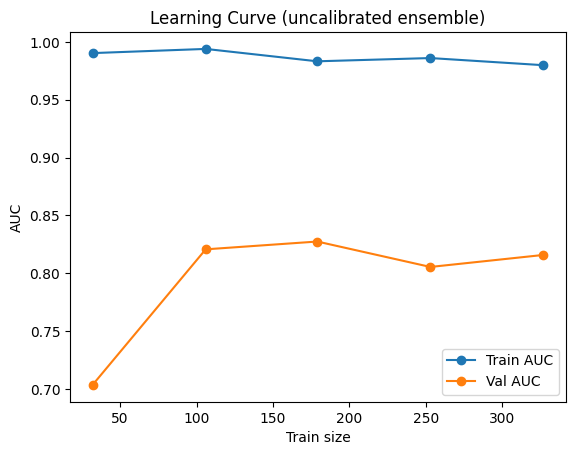

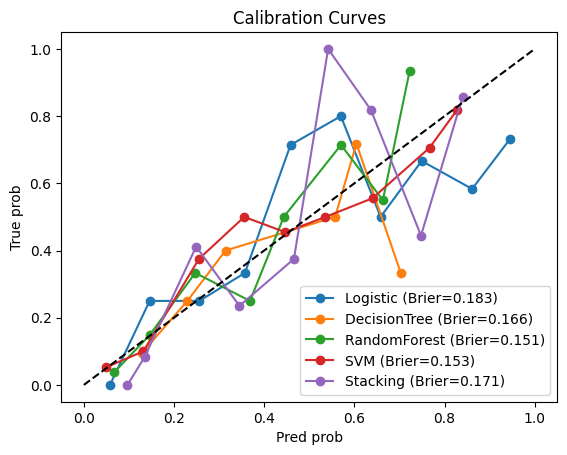

In [11]:
### Ensemble Generalization & Curves (Use raw X_test for calibration curves)

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import learning_curve
import time
import numpy as np
import matplotlib.pyplot as plt

outer_cv = cv  # reuse StratifiedKFold defined earlier (cv=5)
outer_aucs = []

# helper to slice X (works with DataFrame or ndarray)
def slice_X(X, idx):
    if isinstance(X, (pd.DataFrame, pd.Series)):
        return X.iloc[idx]
    else:
        return X[idx]

# ensure y_train is indexable as numpy array
y_train_arr = np.asarray(y_train)

print("Running calibrated outer CV for the ensemble (this can take a while)...")
start_time = time.time()
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train_arr), start=1):
    print(f" Outer fold {fold} / {outer_cv.get_n_splits()} — fitting & calibrating...")
    X_tr = slice_X(X_train, train_idx)
    y_tr = y_train_arr[train_idx]
    X_val = slice_X(X_train, val_idx)
    y_val = y_train_arr[val_idx]

    # Use cv=5 for internal calibration (heavier), keep n_jobs=1 to avoid nested parallelism
    calib_clf = CalibratedClassifierCV(ensemble, cv=5, method='sigmoid', n_jobs=1)

    # Fit (this fits a cloned ensemble and performs calibration)
    calib_clf.fit(X_tr, y_tr)

    # Predict on validation part of outer fold
    probs_val = calib_clf.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, probs_val)
    outer_aucs.append(auc_val)
    print(f"  Fold {fold} calibrated AUC = {auc_val:.3f}")

total_time = time.time() - start_time
print(f"Calibrated Stack CV AUC (outer mean): {np.mean(outer_aucs):.3f}  (computed in {total_time:.0f}s)")

# Learning curve: use the uncalibrated ensemble for speed/stability.
print("Computing learning curve for the (uncalibrated) ensemble...")
sizes, train_scores, val_scores = learning_curve(
    ensemble, X_train, y_train, cv=outer_cv, scoring='roc_auc', n_jobs=N_JOBS,
    train_sizes=np.linspace(0.1, 1.0, 5)
)
plt.figure()
plt.plot(sizes, train_scores.mean(axis=1), 'o-', label='Train AUC')
plt.plot(sizes, val_scores.mean(axis=1), 'o-', label='Val AUC')
plt.title('Learning Curve (uncalibrated ensemble)')
plt.xlabel('Train size')
plt.ylabel('AUC')
plt.legend()
plt.show()

# Calibration curves (plot using the already-fitted calibrated models)
plt.figure()
for name, mdl in calibrated_models.items():
    try:
        # IMPORTANT: pass raw X_test — the calibrated pipeline wraps preprocessing internally
        probs = mdl.predict_proba(X_test)[:, 1]
        prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
        brier = brier_score_loss(y_test, probs)
        plt.plot(prob_pred, prob_true, 'o-', label=f"{name} (Brier={brier:.3f})")
    except Exception as e:
        print(f" Warning: could not compute calibration curve for {name}: {e}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Pred prob')
plt.ylabel('True prob')
plt.title('Calibration Curves')
plt.legend()
plt.show()



**SHAP explainability (mapped to original column names)**

*A. What this cell does*

- Locates the fitted Random Forest classifier, ensures the inference pipeline’s selector is fitted (fitting the selector on SMOTE-resampled data if necessary), transforms test data and computes SHAP TreeExplainer values, producing a SHAP summary plot and a top-10 feature importances CSV.

*B. Methods used & why*

- SHAP TreeExplainer: provides local and global explanations for tree-based models. It yields additive feature contributions to individual predictions, allowing interpretation of which morphological markers push predictions toward malignant or benign.

- Fitting the inference selector on SMOTE-resampled data mirrors the conditions under which selection occurred during training — this keeps the mapping between original features and transformed features consistent for interpretation.

*C. Output analysis*

*Machine-learning interpretation*

- The computed top-importance features (by mean |SHAP|) were:

 1. concave points_se (importance ≈ 0.1588)

 2. symmetry_se (importance ≈ 0.1531)

 3. smoothness_se (importance ≈ 0.0503)

 These three features dominate the model’s explanations on the test set. The SHAP summary dot plot (the figure shown) indicates the directionality of the effects: for concave points_se, red (high) points are primarily on the right (positive SHAP), which means higher concave points_se contributes positively toward the model predicting malignancy. For symmetry_se and smoothness_se the color-to-SHAP patterns indicate how higher or lower values push predictions.

*Medical interpretation*

- The features align with clinical morphological expectations:

 - Concave points quantify irregularities or indentations on the cell/tumor boundary; higher values indicate more pronounced irregularities and are often associated with malignancy. SHAP indicates that larger concave points_se increases predicted malignancy risk.

 - Symmetry measures how symmetric the cell/tumor shape is; lower symmetry (greater asymmetry) is typically associated with malignancy. The SHAP directionality indicates that asymmetry (value direction indicated by color in the plot) contributes meaningfully to malignancy predictions.

 - Smoothness captures edge regularity; malignant lesions often have rougher, less smooth contours. The smaller but non-negligible importance of smoothness_se suggests this physical property matters for the model’s decisions.

- Clinically, these features reflect morphological characteristics pathologists use: irregular, asymmetric, and heterogeneous nuclei/lesions tend to indicate malignancy. The SHAP analysis therefore provides face validity: the model relies on interpretable, biologically plausible cues rather than obscure combinations alone.

*Notes & takeaways*

- SHAP confirms that a small subset of interpretable morphological features drives model predictions. This increases clinician trust and supports the case for integrating the model as a transparent decision-support tool.

Fitting inference pipeline's selector on SMOTE-resampled training data (to mirror training-time selection).
Rendering SHAP summary plot (this may take a few seconds)...


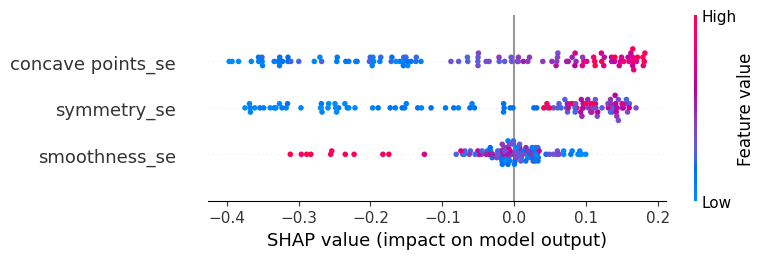


Top-10 SHAP features (mapped to original names):
             feature  importance
2  concave points_se    0.158806
1        symmetry_se    0.153054
0      smoothness_se    0.050309
Saved shap_top10.csv and shap_values.npz


In [12]:
### SHAP explainability (mapped to original X column names)

import numpy as np
import pandas as pd
import shap
from imblearn.over_sampling import SMOTE
from sklearn.exceptions import NotFittedError

# locate trained RandomForest classifier (the underlying clf object)
rf_clf = None
if 'rf_pipeline_full' in globals() and rf_pipeline_full is not None:
    cand = rf_pipeline_full
    if hasattr(cand, "named_steps"):
        rf_clf = cand.named_steps.get("clf", None)
    else:
        rf_clf = cand if hasattr(cand, "predict_proba") else None

if rf_clf is None and 'best_models' in globals():
    cand = best_models.get('RandomForest', None)
    if cand is not None and hasattr(cand, "named_steps"):
        rf_clf = cand.named_steps.get('clf', None)

if rf_clf is None:
    raise RuntimeError("RandomForest classifier not found. Ensure rf_pipeline_full or best_models['RandomForest'] exists and is fitted.")

# original columns (post-VIF)
orig_cols = list(X_train.columns)

# It is necessary to ensure a usable inference pipeline (Have to create one if missing)
if 'inf_pipeline' not in globals() or inf_pipeline is None:
    inf_pipeline = make_inference_pipeline(selector_C=1.0)

# inf_pipeline should be fitted before transform; if not fitted, fitting its selector on SMOTE-resampled train is necessary
def is_selector_fitted(pipeline):
    try:
        sel = pipeline.named_steps.get('feat_sel', None)
        if sel is None:
            return False
        # many selectors expose get_support when fitted
        _ = sel.get_support()
        return True
    except Exception:
        return False

if not is_selector_fitted(inf_pipeline):
    print("Fitting inference pipeline's selector on SMOTE-resampled training data (to mirror training-time selection).")
    sm = SMOTE(random_state=RANDOM_STATE)
    X_res_arr, y_res = sm.fit_resample(X_train, y_train)
    # build DataFrame for consistency
    X_res_df = pd.DataFrame(X_res_arr, columns=orig_cols)
    # Fit the inf_pipeline (imputer+scaler+selector)
    try:
        inf_pipeline.fit(X_res_df, y_res)
    except Exception as e:
        # If inf_pipeline.fit fails, try fitting steps manually
        print("inf_pipeline.fit failed:", e)
        # try fit selector alone after transform by imputer & scaler
        imputer = inf_pipeline.named_steps.get('imputer')
        scaler = inf_pipeline.named_steps.get('scaler')
        sel = inf_pipeline.named_steps.get('feat_sel')
        X_tmp = X_res_df.copy()
        if imputer is not None:
            X_tmp = pd.DataFrame(imputer.fit_transform(X_tmp), columns=X_tmp.columns)
        if scaler is not None:
            X_tmp = pd.DataFrame(scaler.fit_transform(X_tmp), columns=X_tmp.columns)
        if sel is not None:
            sel.fit(X_tmp, y_res)
        # recompose: inf_pipeline should be kept as-is (its selector is now fitted)

# Transform the test set using the fitted inf_pipeline
try:
    X_shap = inf_pipeline.transform(X_test)
except Exception as e:
    print("inf_pipeline.transform failed; attempting manual impute/scale/transform:", e)
    # manual fallback
    X_tmp = X_test.copy()
    imputer = inf_pipeline.named_steps.get('imputer', None)
    scaler = inf_pipeline.named_steps.get('scaler', None)
    sel = inf_pipeline.named_steps.get('feat_sel', None)
    if imputer is not None:
        X_tmp = pd.DataFrame(imputer.transform(X_tmp), columns=X_tmp.columns)
    else:
        X_tmp = X_tmp.values
    if scaler is not None:
        X_tmp = pd.DataFrame(scaler.transform(X_tmp), columns=(X_tmp.columns if hasattr(X_tmp, 'columns') else None))
    if sel is not None:
        X_shap = sel.transform(X_tmp)
    else:
        X_shap = X_tmp

X_shap = np.asarray(X_shap)
if X_shap.ndim != 2:
    raise ValueError(f"X_shap must be 2D; got shape {X_shap.shape}")

# Determine selected columns names
selected_cols = orig_cols.copy()
try:
    sel = inf_pipeline.named_steps.get('feat_sel', None)
    if sel is not None:
        mask = sel.get_support()
        selected_cols = list(np.array(orig_cols)[mask])
except Exception:
    # fall back to generic names if mismatch
    pass

# reconcile lengths
if len(selected_cols) != X_shap.shape[1]:
    # try recover using selector.get_support()
    try:
        mask = sel.get_support()
        sel_names = list(np.array(orig_cols)[mask])
        if len(sel_names) == X_shap.shape[1]:
            selected_cols = sel_names
        else:
            selected_cols = [f"f{i}" for i in range(X_shap.shape[1])]
    except Exception:
        selected_cols = [f"f{i}" for i in range(X_shap.shape[1])]

# Compute SHAP using TreeExplainer (works for RandomForest)
explainer = shap.TreeExplainer(rf_clf)
shap_vals_raw = explainer.shap_values(X_shap)

# Normalize to 2D (n_samples, n_features) # shap may return list for multiclass
if isinstance(shap_vals_raw, (list, tuple)):
    # take class-1 explanations if present else the first
    shap_arr = np.asarray(shap_vals_raw[1]) if len(shap_vals_raw) > 1 else np.asarray(shap_vals_raw[0])
else:
    shap_arr = np.asarray(shap_vals_raw)

# If shap_arr is 3D, try collapse to (n_samples, n_features)
if shap_arr.ndim == 3:
    # heuristic collapse: try shape patterns
    if shap_arr.shape[0] == X_shap.shape[0]:
        shap_to_plot = shap_arr[:, :, -1]
    elif shap_arr.shape[1] == X_shap.shape[0]:
        shap_to_plot = shap_arr[-1, :, :]
    else:
        shap_to_plot = shap_arr.reshape(X_shap.shape[0], -1)
elif shap_arr.ndim == 2:
    shap_to_plot = shap_arr
else:
    raise ValueError(f"Unexpected SHAP array shape: {shap_arr.shape}")

if shap_to_plot.ndim != 2:
    raise ValueError(f"SHAP values must be 2D after normalization; got {shap_to_plot.shape}")

# build DataFrame with mapped feature names and plot
X_shap_df = pd.DataFrame(X_shap, columns=selected_cols)

print("Rendering SHAP summary plot (this may take a few seconds)...")
shap.summary_plot(shap_to_plot, X_shap_df, feature_names=X_shap_df.columns)

imp = np.abs(shap_to_plot).mean(axis=0)
shap_df = pd.DataFrame({"feature": X_shap_df.columns, "importance": imp}).sort_values("importance", ascending=False).head(10)

print("\nTop-10 SHAP features (mapped to original names):")
print(shap_df)

# Save small artifacts locally for later use
try:
    shap_df.to_csv("shap_top10.csv", index=False)
    np.savez_compressed("shap_values.npz", shap_values=shap_to_plot, X_shap=X_shap, feature_names=np.array(X_shap_df.columns))
    print("Saved shap_top10.csv and shap_values.npz")
except Exception as e:
    print("Could not save SHAP artifacts:", e)



**Save models + preprocessing + artifacts**

*A. What this cell does*

- Re-fits the inference pipeline on SMOTE-resampled training data so the inference selector matches training selection.

- Saves the fitted inference pipeline (joblib), calibrated models, stacking calibration wrapper, selected features list, SHAP artifacts (CSV and compressed NPZ), thresholds JSON, and results summary.

*B. Methods used & why*

- Fitting the inference selector on SMOTE data preserves the behavior observed during training (feature selector learned in the presence of SMOTE). Saving artifacts creates reproducible artifacts for deployment and future audits.

*C. Output analysis*

*Machine-learning interpretation*

- All relevant artifacts were saved successfully: inference_pipeline.pkl, calibrated_models.pkl, stack_calib.pkl, selected_features_post_vif.csv, shap_top10.csv, results_summary.csv, and thresholds.json. This guarantees that the exact preprocessing and decision logic can be reloaded for deployment or further validation without retraining. Re-fitting the inference selector on SMOTE-resampled training data is consistent with the pipeline design, ensuring feature selection matches the model’s training environment.

*Medical / operational interpretation*

- Saving calibrated models and thresholds is essential for clinical translation: it enables deterministic replication of predicted probabilities and clinical decision thresholds (e.g., the F2-tuned threshold). For regulatory or audit purposes, preserving both models and feature exports documents the provenance of predictions and facilitates retrospective review of model-driven decisions.



In [13]:
### save models + preprocessing + artifacts

import joblib
import numpy as np
import pandas as pd
import json
import os
from imblearn.over_sampling import SMOTE

out_dir = "."
os.makedirs(out_dir, exist_ok=True)

# Fit a final inference pipeline for deployment and saving
# inf_pipeline will re-fit on SMOTE-resampled training data
try:
    sm = SMOTE(random_state=RANDOM_STATE)
    X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
    # convert to DataFrame with original post-VIF column names
    X_res_df = pd.DataFrame(X_resampled, columns=list(X_train.columns))
    # Fit inference pipeline (imputer -> scaler -> selector)
    if 'inf_pipeline' not in globals() or inf_pipeline is None:
        inf_pipeline = make_inference_pipeline(selector_C=1.0)
    print("Fitting inference pipeline on SMOTE-resampled training data (for deployment consistency)...")
    inf_pipeline.fit(X_res_df, y_resampled)
    # Save the fitted inference pipeline
    joblib.dump(inf_pipeline, os.path.join(out_dir, "inference_pipeline.pkl"), compress=3)
    print("Saved inference_pipeline.pkl (fitted on SMOTE-resampled training data).")
except Exception as e:
    print("Error fitting/saving inference pipeline:", e)

# Save calibrated models & stacking object if present
try:
    if 'calibrated_models' in globals():
        joblib.dump(calibrated_models, os.path.join(out_dir, "calibrated_models.pkl"), compress=3)
    if 'stack_calib' in globals():
        joblib.dump(stack_calib, os.path.join(out_dir, "stack_calib.pkl"), compress=3)
    print("Saved calibrated_models.pkl and stack_calib.pkl (if they existed).")
except Exception as e:
    print("Warning: Could not save calibrated models:", e)

# Save selected features and results (if present)
if 'selected_cols' in globals():
    try:
        pd.Series(selected_cols).to_csv(os.path.join(out_dir, "selected_features_post_vif.csv"), index=False)
        print("Saved selected_features_post_vif.csv")
    except Exception as e:
        print("Could not save selected_features_post_vif.csv:", e)

if 'shap_df' in globals():
    try:
        shap_df.to_csv(os.path.join(out_dir, "shap_top10.csv"), index=False)
        print("Saved shap_top10.csv")
    except Exception as e:
        print("Could not save shap_top10.csv:", e)

if 'results_df' in globals():
    try:
        results_df.to_csv(os.path.join(out_dir, "results_summary.csv"), index=False)
        print("Saved results_summary.csv")
    except Exception as e:
        print("Could not save results_summary.csv:", e)

# Save thresholds dictionary (from threshold optimization in CELL 9)
if 'thresholds' in globals():
    try:
        with open(os.path.join(out_dir, "thresholds.json"), "w") as fh:
            json.dump({k: float(v) for k, v in thresholds.items()}, fh, indent=2)
        print("Saved thresholds.json")
    except Exception as e:
        print("Could not save thresholds.json:", e)

print("All available artifacts saved (where possible) to the working directory.")


Fitting inference pipeline on SMOTE-resampled training data (for deployment consistency)...
Saved inference_pipeline.pkl (fitted on SMOTE-resampled training data).
Saved calibrated_models.pkl and stack_calib.pkl (if they existed).
Saved selected_features_post_vif.csv
Saved shap_top10.csv
Saved results_summary.csv
Saved thresholds.json
All available artifacts saved (where possible) to the working directory.


**Final conclusion**

**Summary of findings**

The modeling pipeline, from robust preprocessing (VIF filtering, winsorization) through SMOTE-aware training pipelines, grid search hyperparameter tuning, probability calibration, and threshold tuning, produced discriminative and clinically interpretable classifiers for the Breast Cancer Wisconsin Diagnostic dataset. The best discriminators (SVM and Random Forest) achieved AUCs ≈ 0.85, while logistic regression and stacking yielded AUC ≈ 0.81. Calibration improved probabilistic fidelity across all models, and SHAP analysis identified a small, clinically meaningful set of morphological features driving predictions.

**Machine-learning conclusions**

1. **Discrimination:** RF and SVM show the strongest ranking ability (highest AUCs). This suggests that nonlinear decision boundaries and ensemble averaging capture the structure of the morphological features better than a single tree or a strongly regularized linear model.

2. **Calibration:** Platt (sigmoid) calibration on an independent fold consistently improved Brier scores and produced probability estimates that better align with observed frequencies — essential when model outputs will inform clinical probabilities.

3. **Operating point selection:** Optimizing thresholds for F2 achieved very high sensitivity (up to 95% for SVM) at the cost of specificity. This is an explicit, auditable trade-off that should be driven by clinical priorities.

4. **Generalization:** Outer calibrated CV (mean AUC ≈ 0.83) and learning curves indicate good but not perfect generalization; a nontrivial train/validation gap suggests the models have capacity to overfit and may benefit from more data or stricter regularization to reduce variance.

5. **Interpretability:** SHAP confirms that model behavior is dominated by pathologically meaningful features (concave points, symmetry, smoothness), increasing trustworthiness.

**Clinical conclusions and recommendations**

1. **Role in care:** Given sensitivity and AUC levels, the models are promising as adjunctive decision-support tools or triage aids (e.g., flagging cytology images for expedited review or biopsy consideration). They are not yet a stand-alone diagnostic substitute for histopathology.

2. **Threshold policy:** The low thresholds chosen to optimize F2 are appropriate when the clinical priority is to minimize missed malignancies (FN). However, the corresponding increase in false positives must be weighed against resource implications (additional imaging, biopsies) and patient experience. Stakeholders should define acceptable false positive rates before operational deployment.

3. **Calibration use:** Because calibrated probabilities were demonstrably better after Platt scaling, any clinical deployment that uses risk thresholds (rather than hard class labels) should rely on the calibrated outputs rather than raw classifier scores.

4. **Interpretability & clinician engagement:** The model’s reliance on interpretable morphological features supports clinician acceptability. Presenting SHAP-based explanations at the individual case level (e.g., “high concave points_se increased malignancy risk”) will help clinicians understand and validate model suggestions.

5. **Validation & next steps:** Before clinical use, external validation on independent cohorts (other institutions, imaging pipelines) is essential to assess robustness across practice variability. The learning curve implies that additional labeled data will likely yield incremental improvements in validation AUC and reduce variance.

**Caveats & limitations**

- The dataset is moderate in size (n=569) and originates from a specific data-generating process; generalization to other populations or imaging/segmentation protocols is not guaranteed.

- Thresholds chosen on a modest calibration set (n=46) are informative but should be re-assessed or re-estimated on larger calibration sets in external cohorts.

- The models optimize different risk trade-offs; selecting a single “best” model must be grounded in clinical preferences, cost models, and patient priorities.